In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

/Users/prince/Documents/Agentic_RAG_Using_langGraph/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/Users/prince/Documents/Agentic_RAG_Using_langGraph/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
os.environ["LANGSMITH_PROJECT"]="TestProject"

In [3]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"] ="true"


In [4]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x15e2d8cd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x15e57ee50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [6]:
## Graph with tool call

from langchain_core.tools import tool

@tool
def add(a:float, b:float):
    """add two numbers"""
    return a+b


tools=[add]
tool_node=ToolNode([add])
llm_with_tool=llm.bind_tools([add])

def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}

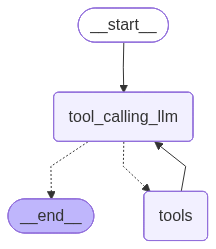

In [7]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
response=graph.invoke({"messages":"What is machine learning"})

In [9]:
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='e9c747c2-f318-4472-a509-eb71b54dd555'),
  AIMessage(content='**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on giving computers the ability to learn from data rather than following strictly programmed instructions. In other words, instead of writing explicit rules for every possible situation, we design algorithms that can automatically discover patterns, relationships, or decision‑making strategies from examples.\n\n---\n\n## Core Idea\n\n1. **Data → Model → Prediction/Decision**  \n   - **Data**: A collection of examples (e.g., images, text, sensor readings).  \n   - **Model**: A mathematical structure (e.g., a set of parameters, a decision tree, a neural network) that captures patterns in the data.  \n   - **Learning algorithm**: A procedure that adjusts the model’s parameters so that the model performs well on a given task (e.g., clas

In [10]:
response=graph.invoke({"messages":"can you add 5 and 6?"})

In [11]:
response

{'messages': [HumanMessage(content='can you add 5 and 6?', additional_kwargs={}, response_metadata={}, id='1d88b970-1021-4837-80ea-8d8722795b00'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks to add 5 and 6. Use function add.', 'tool_calls': [{'id': 'fc_41eb4c20-dcbd-49ac-8efa-74e5607a8527', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 129, 'total_tokens': 177, 'completion_time': 0.101725792, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.004865899, 'prompt_tokens_details': None, 'queue_time': 0.05333335, 'total_time': 0.106591691}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1293-a6cf-79f0-a833-56136dc7d016-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 6}, 'id'